In [29]:
import numpy as np 
import numpy.linalg as la
from numpy.linalg import inv, eig

#the matrix
rows = 3; cols = 3
A = np.array([[1,2,3],[0, -4, 1],[0, 3, -1]])
print("A=")
print(A)

#calculate the determinant
det = la.det(A)
print(f"Determinant of M is: {det:}")

#solving equations
M= np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(f"Matrix M:\n{M}")
b = np.array([2,2,-1])
Minv = inv(M)
xyz = Minv@b
print(f"\nSolution: x, y, z = {xyz}")

#is A orthogonal??
Minv = inv(A)
print("The inverse of A=")
print(Ainv)
Atrans = M.T
print(f"Transpose of A :\n{Atrans}")
#It is not orthogonal cause the traspose and the inverse of A are different, should be the same cause if I multiply them they should give I

#calculate eigenvalues
eigenvalues, v= la.eig(A)
print("Eigenvalues", eigenvalues)

A=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of M is: 1.0
Matrix M:
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

Solution: x, y, z = [10. -1. -2.]
The inverse of A=
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]
Transpose of A :
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]
Eigenvalues [ 1.         -4.79128785 -0.20871215]


In [34]:
import numpy as np
from numpy import sin, cos
from numpy import linalg as la
from numpy.linalg import inv, eig

# Result composed matrix E
def Ex(alpha):
    a = np.radians(alpha)
    return np.array([[1, 0, 0],[0, np.cos(a), np.sin(a)],[0, -np.sin(a), np.cos(a)]])

def Ey(beta):
    b = np.radians(beta)
    return np.array([[np.cos(b), 0, -np.sin(b)],[0, 1, 0],[np.sin(b), 0, np.cos(b)]])

def Ez(gamma):
    g = np.radians(gamma)
    return np.array([[np.cos(g), np.sin(g), 0],[-np.sin(g), np.cos(g), 0],[0, 0, 1]])

# Result 
E = Ez(180 - 123) @ Ey(90 - 27.4) @ Ez(192.25)
print("E =", E)

# Prove composed matrix is a rotation matrix
# A rotation matrix must satisfy: E @ E.T = I  AND  det(E) = +1
EtE = E @ E.T
print("E @ E.T (must equal identity matrix):")
print(np.round(EtE, 8))

det_E = la.det(E)
print(f"det(E) = {det_E:.1f}  (must equal +1)")

# Prove Eigenvalue of 1
Lambda, v = la.eig(E)
print("Lambda, eigenvalues = ", Lambda)

# Find the eigenvalue closest to 1
idx = np.argmin(np.abs(Lambda - 1.0))
print(f"Eigenvalue closest to 1: {Lambda[idx]:.2f}")

# Prove vector v follows from equation (7.16) and has norm of 1 
alpha = 192.25   
delta = 27.4     

alpha_rad = np.radians(alpha)
delta_rad = np.radians(delta)

# Equation (7.16)
v_pole = np.array([np.cos(delta_rad) * np.cos(alpha_rad), np.cos(delta_rad) * np.sin(alpha_rad), np.sin(delta_rad)])

print("Galactic pole vector from eq. (7.16):")
print(f"v = {v_pole}")
print("Expected: [-0.86760081, -0.1883746,  0.46019978]")

norm_v = la.norm(v_pole)
print(f"||v|| = {norm_v:.1f}  (must equal 1.0)")

# Prove E @ v = [0, 0, 1] 
v2 = E @ v_pole
print("Rotated vector v2 = E @ v:")
print(f"v2 = {np.round(v2, 8)}")

E = [[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
E @ E.T (must equal identity matrix):
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]
det(E) = 1.0  (must equal +1)
Lambda, eigenvalues =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
Eigenvalue closest to 1: 1.00+0.00j
Galactic pole vector from eq. (7.16):
v = [-0.86760081 -0.1883746   0.46019978]
Expected: [-0.86760081, -0.1883746,  0.46019978]
||v|| = 1.0  (must equal 1.0)
Rotated vector v2 = E @ v:
v2 = [0. 0. 1.]


Polynomial coefficients a (from x^0 to x^(n-1)): [ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331359e+01  2.91867714e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


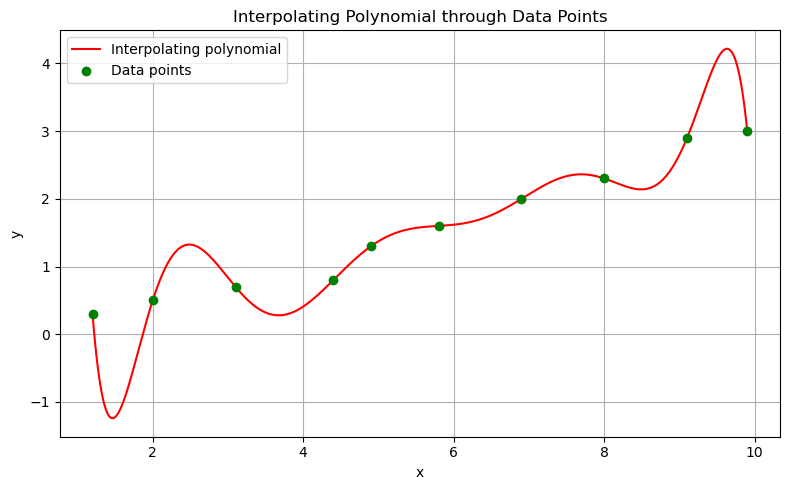

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Data points
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)

# Build Vandermonde matrix A using loops 
# Each row i : [x_i^0, x_i^1, x_i^2, ..., x_i^(n-1)]
# So that A @ a = y solves for polynomial coefficients a
A = np.zeros((n, n))
for i in range(n):           # loop over rows (data points)
    for j in range(n):       # loop over columns (polynomial powers)
        A[i, j] = x[i]**j

# Solve for coefficients 
a = np.linalg.solve(A, y)
print(f"Polynomial coefficients a (from x^0 to x^(n-1)): {a}")

# Evaluate the interpolating polynomial on a fine grid 
x_fine = np.linspace(x[0], x[-1], 500)
y_fine = np.zeros(len(x_fine))

for i, xi in enumerate(x_fine):          # loop over evaluation points, evaluates the polynomial at every x-point
    for j in range(n):                   # sum each term a_j * xi^j
        y_fine[i] += a[j] * xi**j

# Plot 
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_fine, label='Interpolating polynomial', color='red')
plt.scatter(x, y, color='green', zorder=5, label='Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolating Polynomial through Data Points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

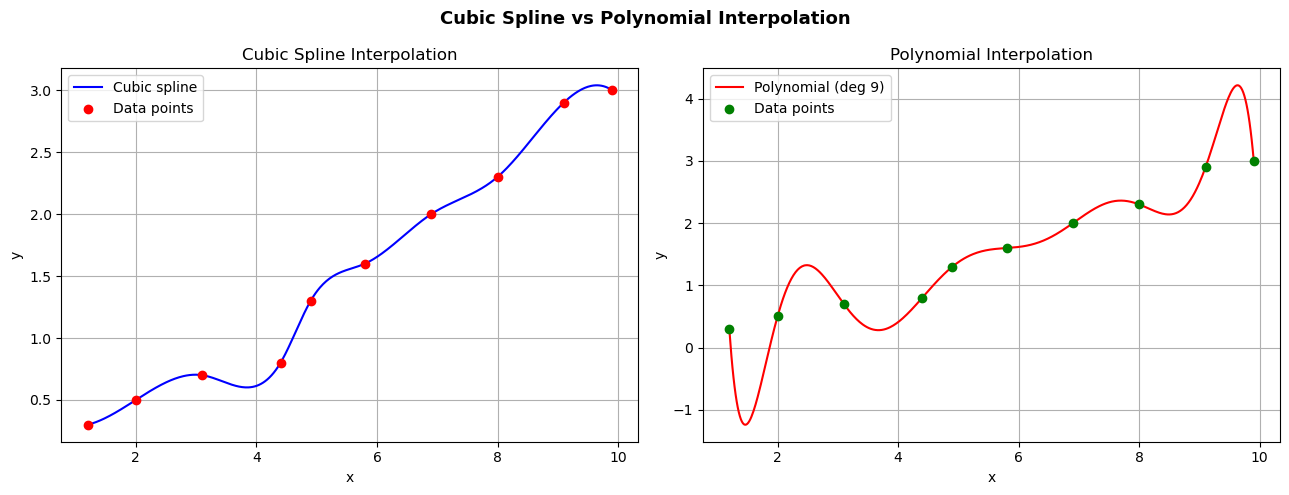


Comparison :
- The cubic spline follows the data points better without any exagerated curves.
- Polynomial shows Runge's phenomenon: large oscillations between data points, especially near the edges. Makes it unreliable for predictions.



Input value between 1.2 and 9.9:  3


Interpolated values at x = 3.0:
 Linear: 0.682
 Polynomial: 0.836
 Spline: 0.704


/var/folders/7v/p1sj0g550hdcb0ksj6mvgkrh0000gn/T/ipykernel_1297/1408148723.py:83: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(result) if result.size == 1 else result


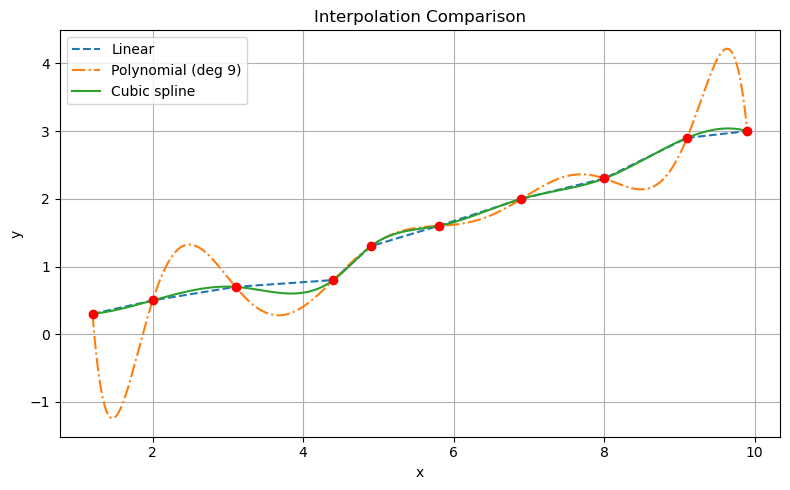

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from numpy.linalg import solve

# Data points
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

# Cubic spline plot vs polynomial 
spline_func = interp1d(x, y, kind='cubic')
x_fine = np.linspace(x[0], x[-1], 500)     # Smooth x-values for plotting

# Polynomial (from Question 7.5) 
n = len(x)
A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        A[i, j] = x[i]**j
a = solve(A, y)

# Evaluate polynomial

y_poly = np.zeros(len(x_fine))
for i, xi in enumerate(x_fine):
    for j in range(n):
        y_poly[i] += a[j] * xi**j

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_fine, spline_func(x_fine), color='blue', label='Cubic spline')
axes[0].scatter(x, y, color='red', zorder=5, label='Data points')
axes[0].set_title('Cubic Spline Interpolation')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(x_fine, y_poly, color='red', label='Polynomial (deg 9)')
axes[1].scatter(x, y, color='green', zorder=5, label='Data points')
axes[1].set_title('Polynomial Interpolation')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Cubic Spline vs Polynomial Interpolation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Comparison :
- The cubic spline follows the data points better without any exagerated curves.
- Polynomial shows Runge's phenomenon: large oscillations between data points, especially near the edges. Makes it unreliable for predictions.
""")

# Interpolation Class

class Interpolation:
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)

        # Build interpolation functions once
        self.linear = interp1d(self.x, self.y, kind='linear')
        self.spline = interp1d(self.x, self.y, kind='cubic')

        # Degree n-1 polynomial
        coeffs = np.polyfit(self.x, self.y, len(self.x)-1)
        self.polynomial = np.poly1d(coeffs)

    def interpolate(self, x_query, method='spline'):
        x_query = np.atleast_1d(x_query)

        if np.any(x_query < self.x.min()) or np.any(x_query > self.x.max()):
            raise ValueError("x_query outside interpolation range")

        if method == 'linear':
            result = self.linear(x_query)
        elif method == 'polynomial':
            result = self.polynomial(x_query)
        elif method == 'spline':
            result = self.spline(x_query)
        else:
            raise ValueError("method must be 'linear', 'polynomial', or 'spline'")

        return float(result) if result.size == 1 else result

    def plot(self):
        x_fine = np.linspace(self.x[0], self.x[-1], 500)

        plt.figure(figsize=(8,5))
        plt.plot(x_fine, self.linear(x_fine), '--', label='Linear')
        plt.plot(x_fine, self.polynomial(x_fine), '-.', label='Polynomial (deg 9)')
        plt.plot(x_fine, self.spline(x_fine), '-', label='Cubic spline')
        plt.scatter(self.x, self.y, color='red', zorder=5)

        plt.title('Interpolation Comparison')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# Use the class

interp = Interpolation(x, y)

x_test = float(input(f"Input value between {min(x)} and {max(x)}: "))

print(f"Interpolated values at x = {x_test}:")
print(f" Linear: {interp.interpolate(x_test, 'linear'):.3f}")
print(f" Polynomial: {interp.interpolate(x_test, 'polynomial'):.3f}")
print(f" Spline: {interp.interpolate(x_test, 'spline'):.3f}")

# Plot all methods
interp.plot()

In [40]:
import numpy as np

# Bilinear interpolation formula : f(x,y) = [1-mu, mu] @ I[i:i+2, j:j+2] @ [1-lambda, lambda].T

# Given pixel grid and interpolation point
I = np.array([[2.0, 4.1],[2.5, 3.8]])

Xip = 0.2
Yip = 0.7

i = int(Yip)          # Row index
j = int(Xip)          # Column index
M = I[i:i+2, j:j+2]   # Slice relevant 2x2 matrix
print("Sliced Matrix:\n", M)

Lambda = Xip - int(Xip)   # Fractional part of x
mu = Yip - int(Yip)   # Fractional part of y

A = np.array([1-mu, mu])
B = np.array([1-Lambda, Lambda])

Iintp = A.T.dot(M).dot(B)
print(f"The interpolated intensity at x,y={Xip},{Yip} is {Iintp:.3f}.")

Sliced Matrix:
 [[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at x,y=0.2,0.7 is 2.658.


leastsq
 a = 69.94 km/s
 b = 64.13 km/s/Mpc (Hubble constant H0)
curve_fit
 a = 69.94 ± 47.32 km/s
 b = 64.13 ± 1.53 km/s/Mpc (Hubble constant H0)


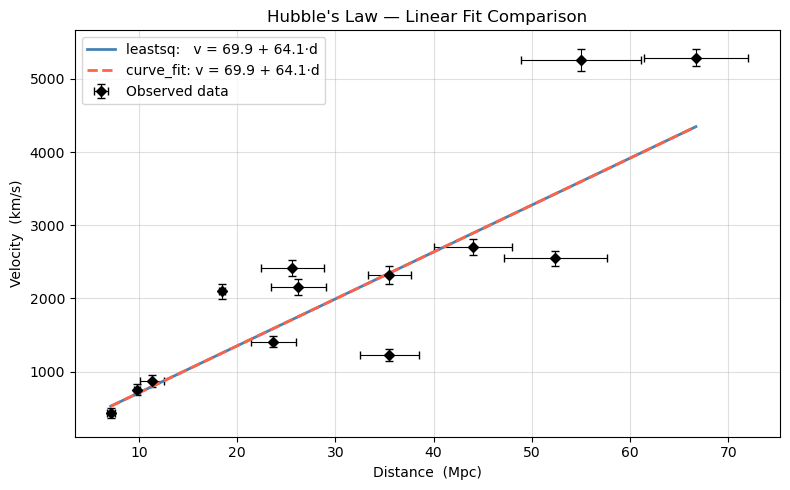

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

# Data 
data = [
   18.49, 2094.75,  0.3, 100,
   35.48, 2320.87,  2.2, 120,
   35.48,  1224.9,  3.0,  80,
   11.34,   872.13, 1.2,  80,
    7.12,   432.2,  0.4,  70,
    9.82,   751.0,  0.3,  75,
   23.66,  1410.0,  2.3,  70,
   44.00,  2700.0,  4.0, 110,
   66.70,  5292.0,  5.3, 120,
   52.40,  2550.0,  5.2, 100,
   55.00,  5253.0,  6.1, 150,
   25.60,  2419.0,  3.2, 110,
   26.19,  2158.0,  2.8, 110
]

data = np.array(data).reshape(-1, 4)
d = data[:, 0]        # distance  (Mpc)
v = data[:, 1]        # velocity  (km/s)
err_d = data[:, 2]    # uncertainty in d
err_v = data[:, 3]    # uncertainty in v 

# Linear model:  v = a + b*d 
def model(d, a, b):
    return a + b * d

# Method 1: scipy.optimize.leastsq()
# leastsq minimises sum(residuals**2); dividing by err_v weights each point
def residuals(params, data):
    a, b = params
    d_ = data[:, 0]
    v_ = data[:, 1]
    err_v_ = data[:, 3]
    return (v_ - model(d_, a, b)) / err_v_   # weighted residuals

params0 = [0.0, 70.0]              # initial guess [a, b]
result  = leastsq(residuals, params0, args=(data,), full_output=True)

a_ls, b_ls = result[0]
print("leastsq")
print(f" a = {a_ls:.2f} km/s")
print(f" b = {b_ls:.2f} km/s/Mpc (Hubble constant H0)")

# Method 2: scipy.optimize.curve_fit() 
# sigma=err_v passes velocity uncertainties; absolute_sigma=True treats them
# as true 1-sigma errors so the covariance matrix is in physical units
beta, pcov = curve_fit(model, d, v, p0=params0, sigma=err_v, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))          # 1-sigma uncertainties on params

a_cf, b_cf = beta
print("curve_fit")
print(f" a = {a_cf:.2f} ± {perr[0]:.2f} km/s")
print(f" b = {b_cf:.2f} ± {perr[1]:.2f} km/s/Mpc (Hubble constant H0)")

# Plot 
d_fit = np.linspace(d.min(), d.max(), 300)

plt.figure(figsize=(8, 5))

# Data with error bars; diamond marker (≠ default circle)
plt.errorbar(d, v, yerr=err_v, xerr=err_d, fmt='D', color='black', markersize=5, capsize=3, elinewidth=0.8, label='Observed data')

# leastsq fit
plt.plot(d_fit, model(d_fit, a_ls, b_ls), color='steelblue', linewidth=2, label=f'leastsq:   v = {a_ls:.1f} + {b_ls:.1f}·d')

# curve_fit fit
plt.plot(d_fit, model(d_fit, a_cf, b_cf), color='tomato', linewidth=2, linestyle='--', label=f'curve_fit: v = {a_cf:.1f} + {b_cf:.1f}·d')

plt.xlabel('Distance  (Mpc)')
plt.ylabel('Velocity  (km/s)')
plt.title("Hubble's Law — Linear Fit Comparison")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
DO GITHUB